In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener, butter, freqs, convolve
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2


In [49]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [50]:
m, n = 400, 10
w = 30  # width of the bump in # nodes
x = np.linspace(0, 1, m, endpoint=False)
mu = np.linspace(0, 1, n, endpoint=False)
xi = np.array([0.6, 0.1, 0.125, 0.35])
sigma = 20
mode = "constant"

In [51]:
print(mu)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [52]:
def plot_paramspace(X):
    fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
    plt.imshow(X, interpolation="none", extent=(0, 1, 0, 1), aspect="auto")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    #ax.set_aspect(1/10)
    plt.show()
    return fig, ax

In [53]:
def bump(x, mu):
    y = np.zeros_like(x)
    i = np.argmin(np.abs(x-mu))
    y[i:(i+w)] = 1.0
    return y

In [54]:
def predict(VT, grid, r, xi):
    method = "linear"
    V_interpolated = np.zeros((r, len(xi)))
    for mode in range(r):
        interpolator = interp1d(grid[0], VT[mode, :], kind=method)
        V_interpolated[mode, :] = interpolator(xi)
    return V_interpolated

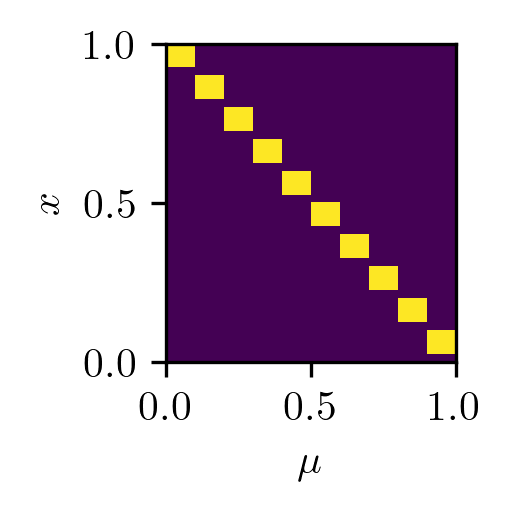

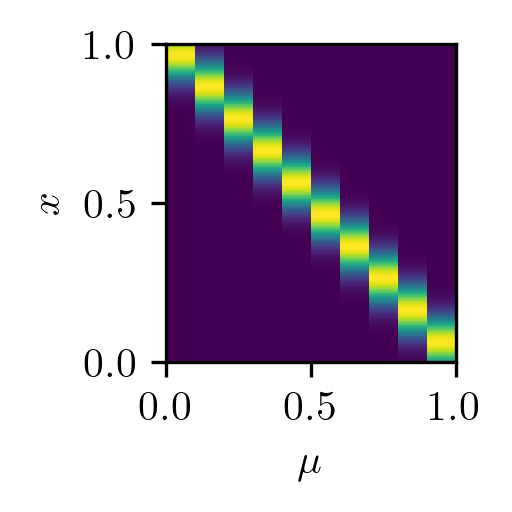

In [55]:
X = np.zeros((m, n))
X_c = np.zeros_like(X)
for j, mu_j in enumerate(mu):
    y = bump(x, mu_j)
    X[:, j] = y
    X_c[:, j] = gaussian_filter1d(y, sigma, mode=mode, cval=0)
plot_paramspace(X)
plt.show()
plot_paramspace(X_c)
plt.show()

In [56]:
U, S, VT = np.linalg.svd(X, False)
U_c, S_c, VT_c = np.linalg.svd(X_c, False)

In [57]:
grid = [mu,]

VT_intp = predict(VT, grid, min(m, n), xi)
X_intp = (U*S) @ VT_intp

VT_intp_c = predict(VT_c, grid, min(m, n), xi)
X_intp_c = (U_c*S_c) @ VT_intp_c

X_exact = np.zeros_like(X_intp)
for j in range(len(xi)):
    X_exact[:, j] = bump(x, xi[j])

In [58]:
kernel_size = len(x) # int(4 * sigma) + 1
psf = cv2.getGaussianKernel(kernel_size, sigma)
psf_f = fft(ifftshift(psf))

psf2 = cv2.getGaussianKernel(kernel_size, sigma*5)
psf2_f = fft(ifftshift(psf))

#X_intp[:, 0] = np.sin(x*2*np.pi * 4.5)

ROM_f = fft(X_intp[:, 0])
sROM_f = fft(X_intp_c[:, 0])
exact_f = fft(X_exact[:, 0])

freq = np.fft.fftfreq(len(ROM_f), x[1]-x[0])

In [ ]:
# for i, sgm in enumerate(sigmas):
#     for k, sz in enumerate(size_filter):
#         for l, ns in enumerate(n_sharpenings):


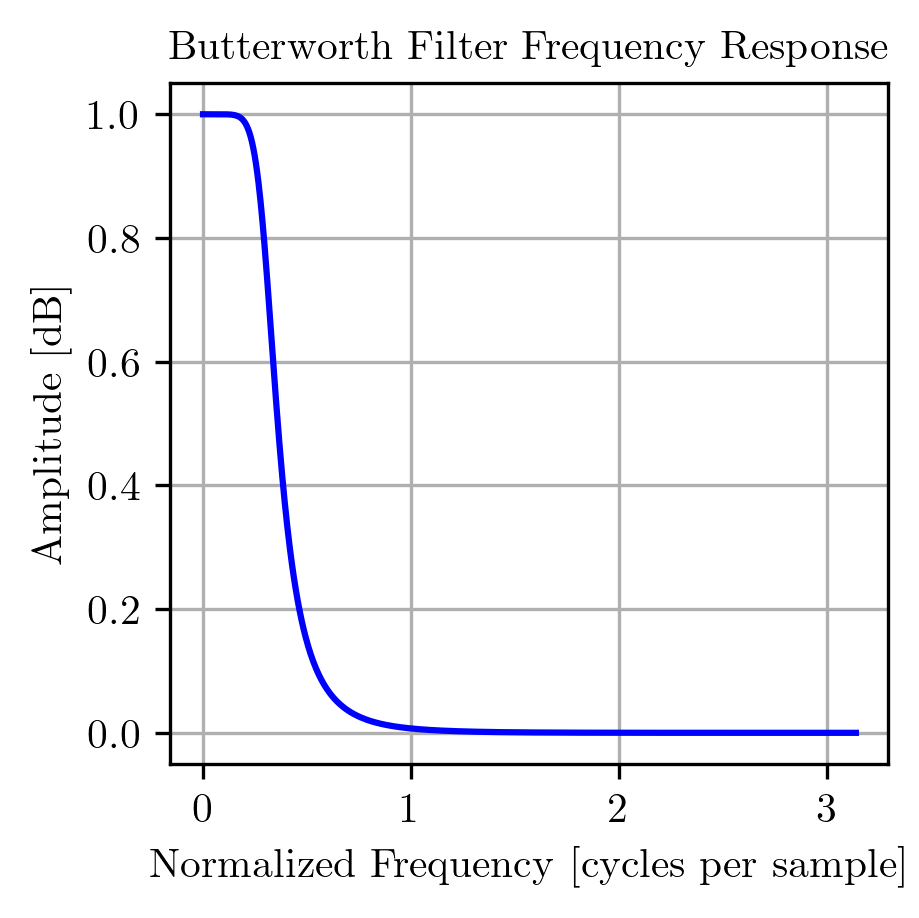

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqz

# Design the Butterworth filter using scipy.signal.butter
# Here, b and a are the numerator and denominator of the filter transfer function
# N: filter order, Wn: cutoff frequency, btype: filter type

N = 4  # Order of the filter
Wn = 0.1  # Cutoff frequency as a fraction of Nyquist rate
b, a = butter(N, Wn, btype='low')
w, h = freqz(b, a, worN=1000)
normalized_frequencies = w / np.pi
normalized_amplitude = np.abs(h)

# Plotting
plt.figure()
plt.plot(w, normalized_amplitude, 'b')
plt.title('Butterworth Filter Frequency Response')
plt.xlabel('Normalized Frequency [cycles per sample]')
plt.ylabel('Amplitude [dB]')
plt.grid()
plt.show()

In [59]:
def gaussian(x, mu, sigma):
    dx = x[1]-x[0]
    sigma_x = sigma*dx
    exponent = ((x - mu)**2 / (2 * sigma_x**2))
    a = 1 / (2 * np.pi * sigma_x)
    res = a * np.exp(-exponent)
    res /= np.sum(res)
    return res

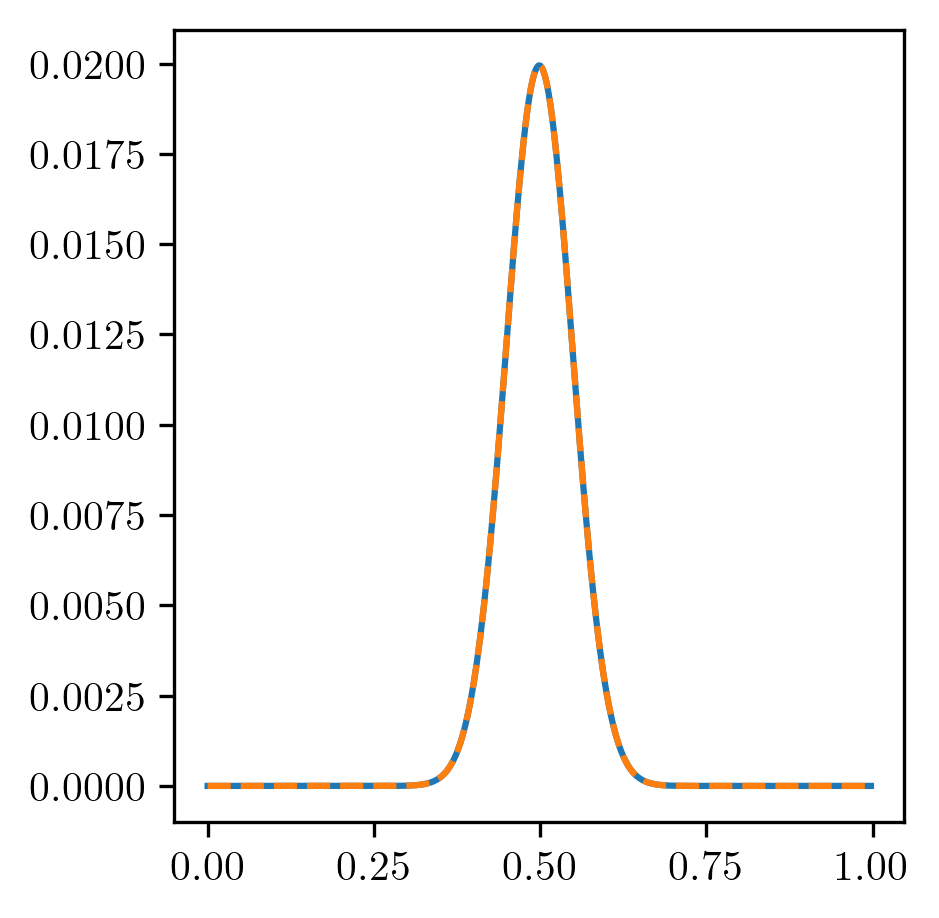

In [60]:
kernel_size = len(x) # int(4 * sigma) + 1
psf = cv2.getGaussianKernel(kernel_size, sigma)
psf_ = gaussian(x, np.mean(x), sigma)
plt.plot(x, psf, "C0-")
plt.plot(x, psf_, "C1--")
#plt.xlim([0.3, 0.7])
plt.show()

C:\Users\florianma\AppData\Local\Temp\ipykernel_4432\1319584785.py:7: RuntimeWarning: invalid value encountered in true_divide
  ideal_filter_f = exact_f/sROM_f
C:\Users\florianma\AppData\Local\Temp\ipykernel_4432\1319584785.py:8: RuntimeWarning: invalid value encountered in true_divide
  ideal_filter_f = sROM_f/ exact_f


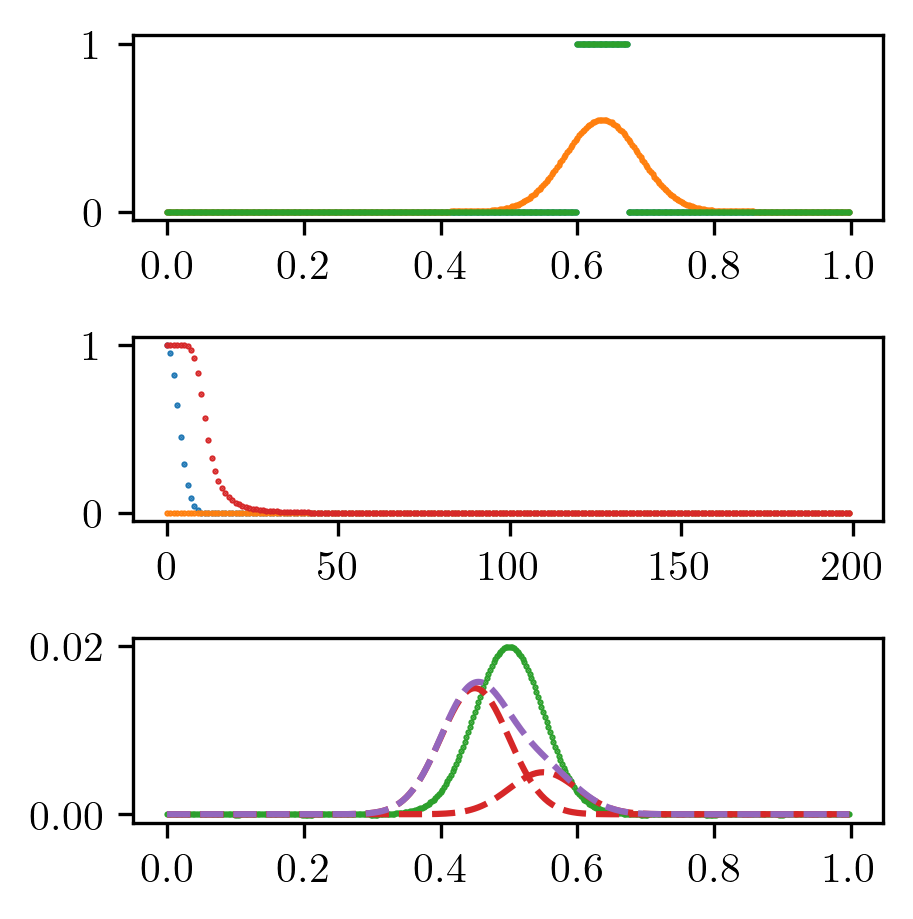

C:\Users\florianma\AppData\Local\Temp\ipykernel_4432\1319584785.py:8: RuntimeWarning: divide by zero encountered in true_divide
  ideal_filter_f = sROM_f/ exact_f


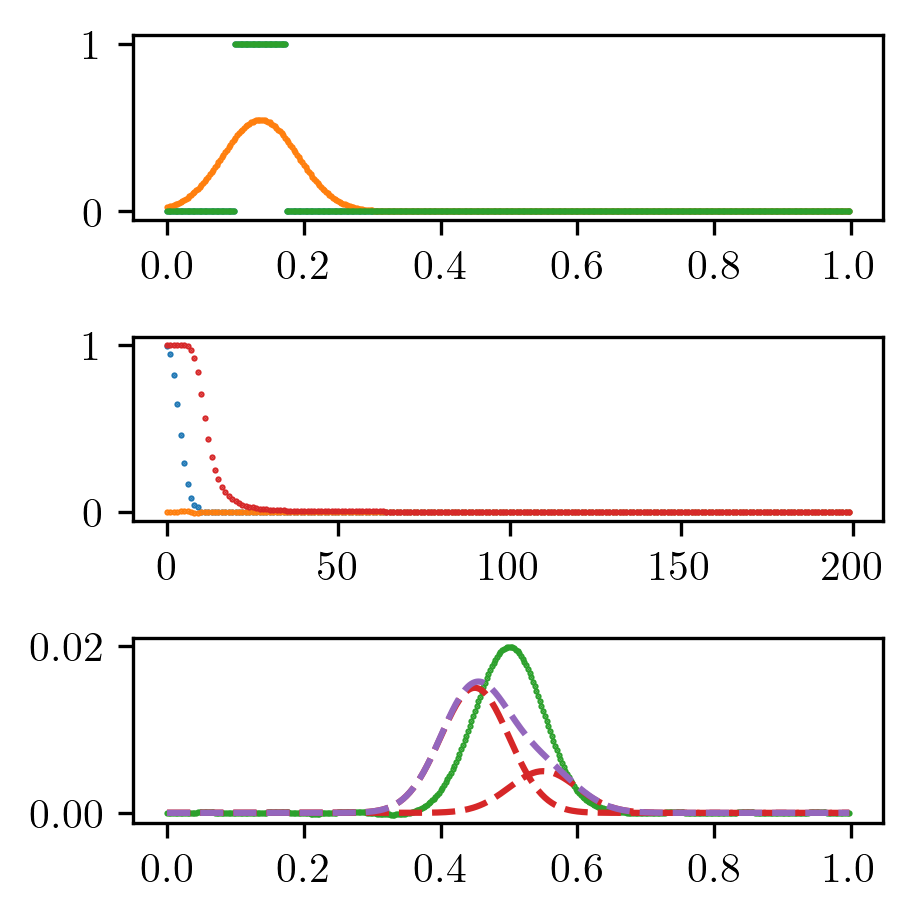

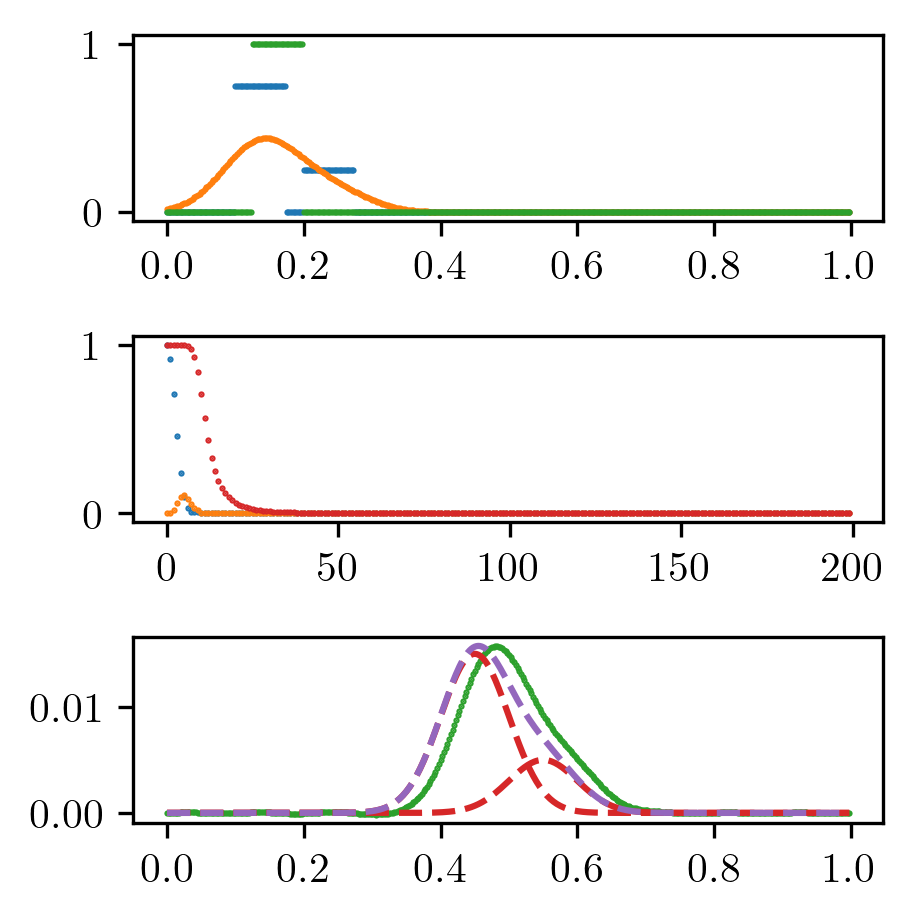

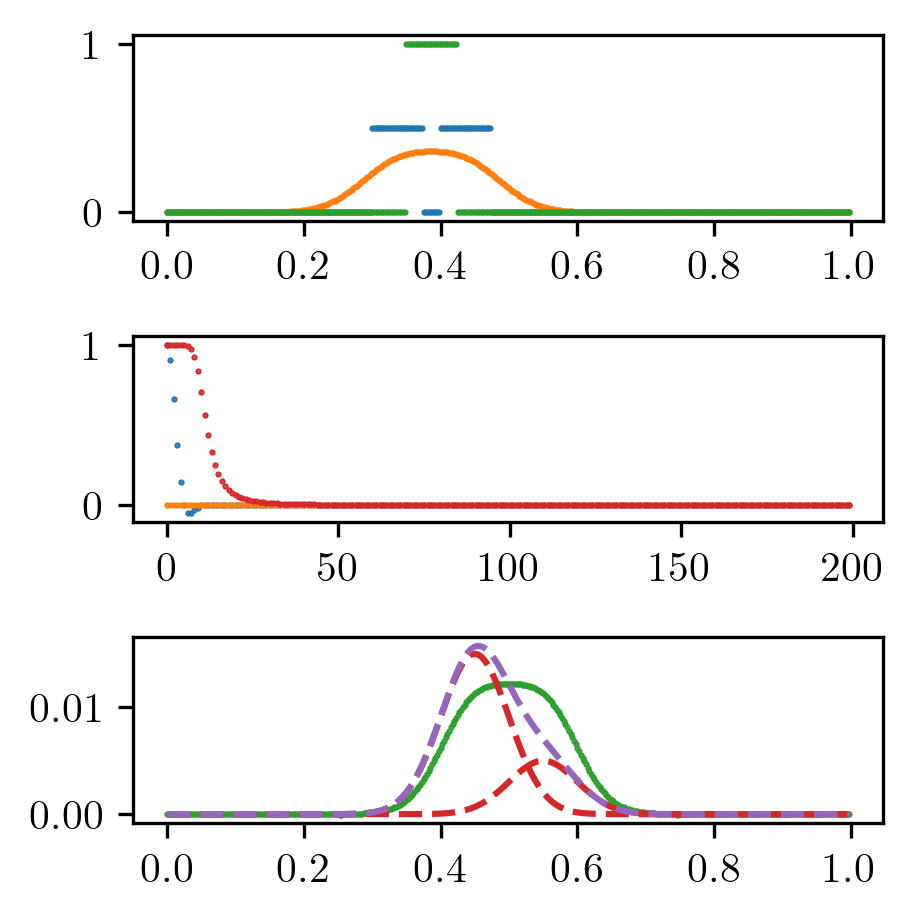

In [61]:
for i in range(len(xi)):
    positiv_only = freq >= 0
#    ROM_f = fft(X_intp[:, i])
    sROM_f = fft(X_intp_c[:, i])
    exact_f = fft(X_exact[:, i])
    
    ideal_filter_f = exact_f/sROM_f
    ideal_filter_f = sROM_f/ exact_f
    cutoff_frequ = 10
    low_pass = (-cutoff_frequ < freq) & (freq < cutoff_frequ)
    ideal_filter_f[~low_pass] = 0
    ideal_filter_f[ideal_filter_f>1e3] = 0
    ideal_filter_f[ideal_filter_f<-1e3] = 0
    
    N = 4  # Order of the filter
    Wn = 0.025  # Cutoff frequency as a fraction of Nyquist rate
    b, a = butter(N, Wn, btype='low')
    w, h = freqz(b, a, worN=len(exact_f))
    #normalized_frequencies = w / np.pi
    butter_filter = np.abs(h)
    #ideal_filter_f = ideal_filter_f*butter_filter

    ideal_filter_f[np.isnan(ideal_filter_f)] = 0
    ideal_filter_s = (ifft(ideal_filter_f)).real

    fig, (ax0, ax1, ax2) = plt.subplots(3, 1)
    #ax1.plot(x, psf, "C1.", ms=1)
    ax0.plot(x, X_intp[:, i], "C0.", ms=1)
    ax0.plot(x, X_intp_c[:, i], "C1.", ms=1)
    ax0.plot(x, X_exact[:, i], "C2.", ms=1)

    ax1.plot(freq[positiv_only], ideal_filter_f[positiv_only].real, "C0.", label="cos", ms=1)
    ax1.plot(freq[positiv_only], ideal_filter_f[positiv_only].imag, "C1.", label="sin", ms=1)
    ax1.plot(freq[positiv_only], normalized_amplitude[:200].real, "C3.", label="sin", ms=1)
    #ax1.set_xlim([0, len(x)/2])
    #ax1.set_ylim([-1e-6, 1e-6])
    ax2.plot(x, ifftshift(ideal_filter_s), "C2.", ms=1)
    g1 = gaussian(x, 0.45, sigma)
    g2 = gaussian(x, 0.55, sigma)
    ax2.plot(x, g1*0.75, "C3--", ms=1)
    ax2.plot(x, g2*0.25, "C3--", ms=1)
    ax2.plot(x, g1*0.75+g2*0.25, "C4--", ms=1)
    plt.show()

In [84]:
.5-0.025


0.475

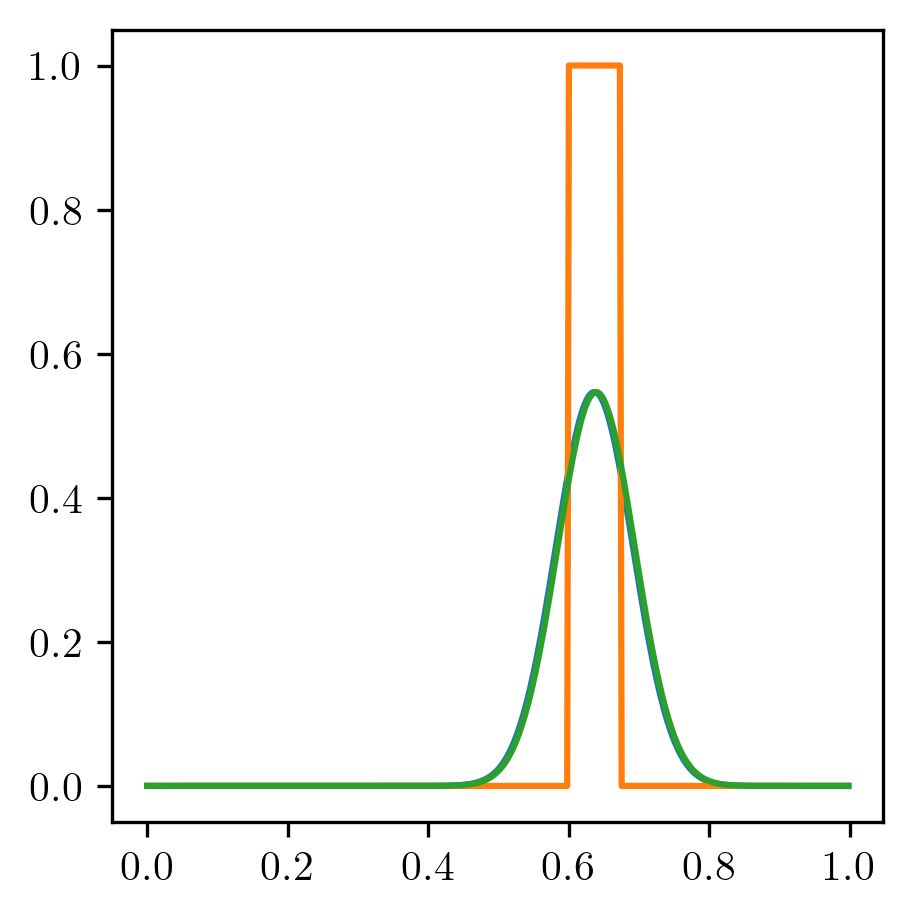

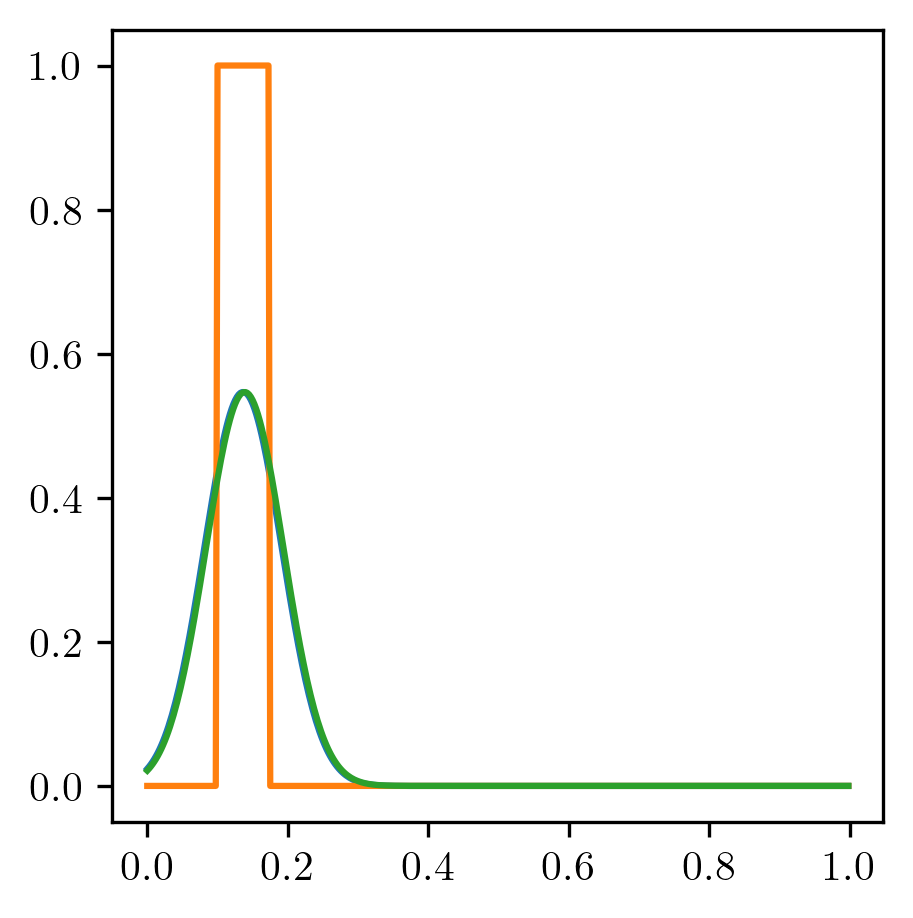

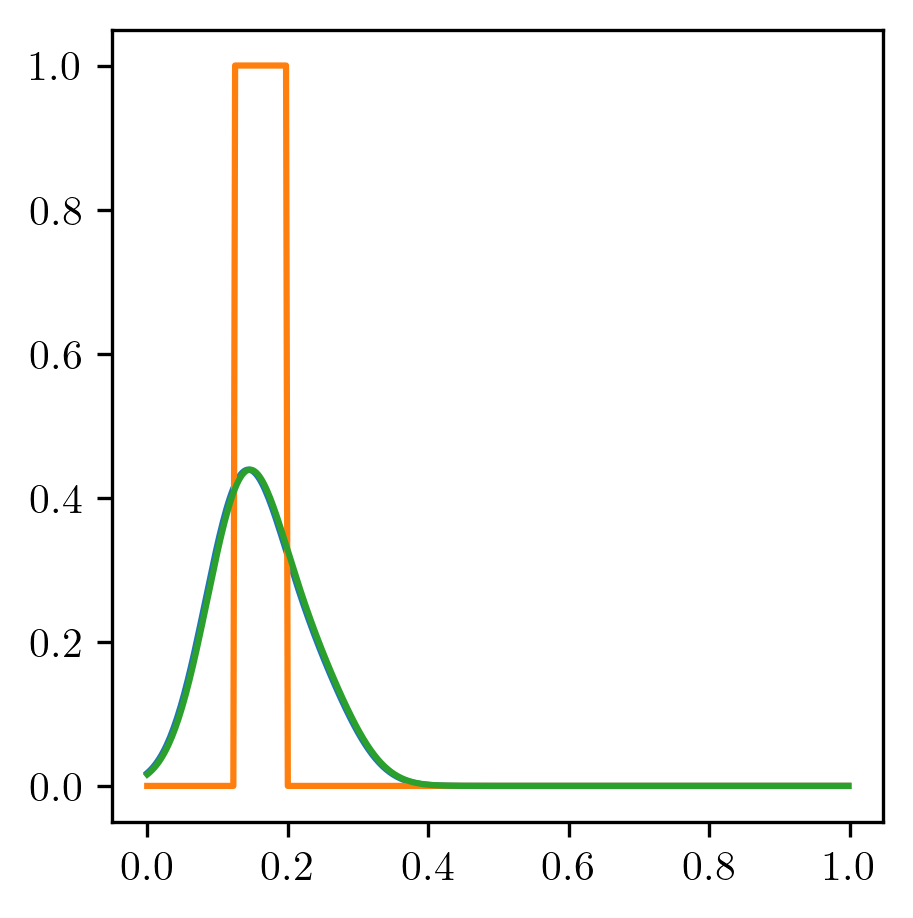

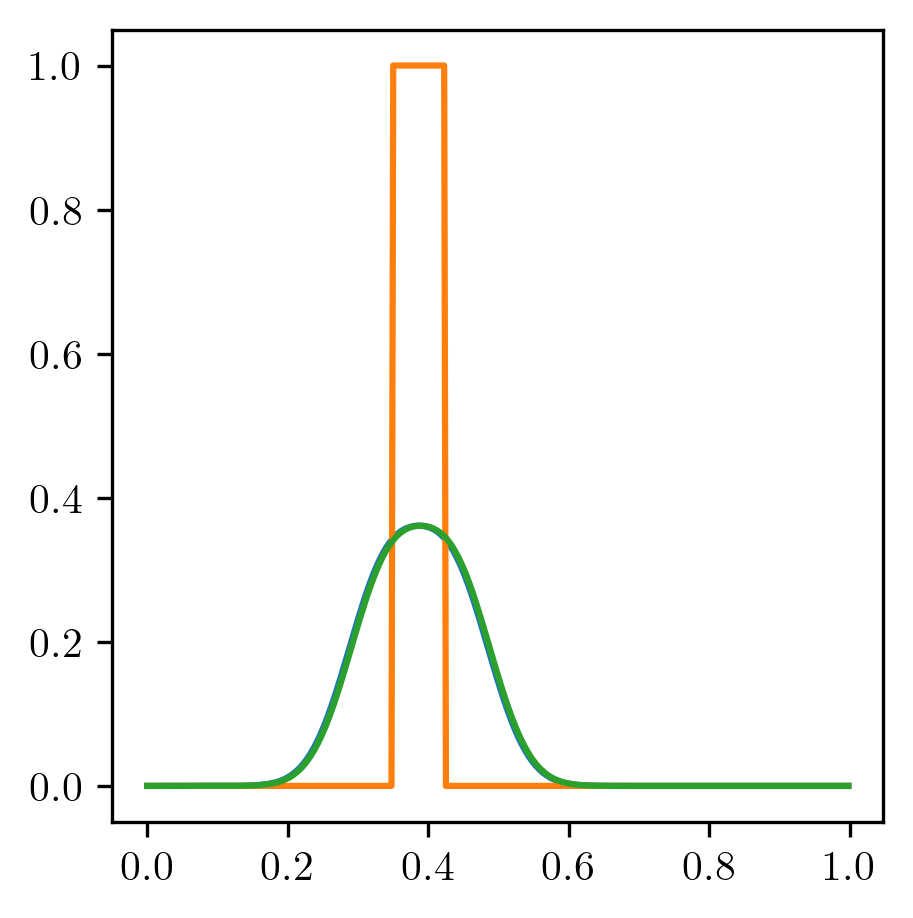

In [86]:

dists = [[0, 0.1], [0, 0.1], [-0.025, 0.075], [-.05, .05]]
weights = [[1, 0], [1, 0], [0.75, 0.25], [.5, .5]]
for i in range(len(xi)):
    g1 = weights[i][0]*gaussian(x, 0.5+dists[i][0], sigma)
    g2 = weights[i][1]*gaussian(x, 0.5+dists[i][1], sigma)
    g = g1+g2
    
    X_analztic = gaussian_filter1d(X_exact[:, i], sigma, mode=mode, cval=0)
    X_analztic2 = convolve(X_exact[:, i], g, mode="same")
    ROM_f = fft(X_intp[:, i])
    sROM_f = fft(X_intp_c[:, i])
    exact_f = fft(X_exact[:, i])
    
    g1_f = fft(ifftshift(g1))
    g2_f = fft(ifftshift(g2))
   # plt.plot(x, X_intp[:, i])
    plt.plot(x, X_intp_c[:, i])
    plt.plot(x, X_exact[:, i])
    plt.plot(x, X_analztic2)
    plt.show()


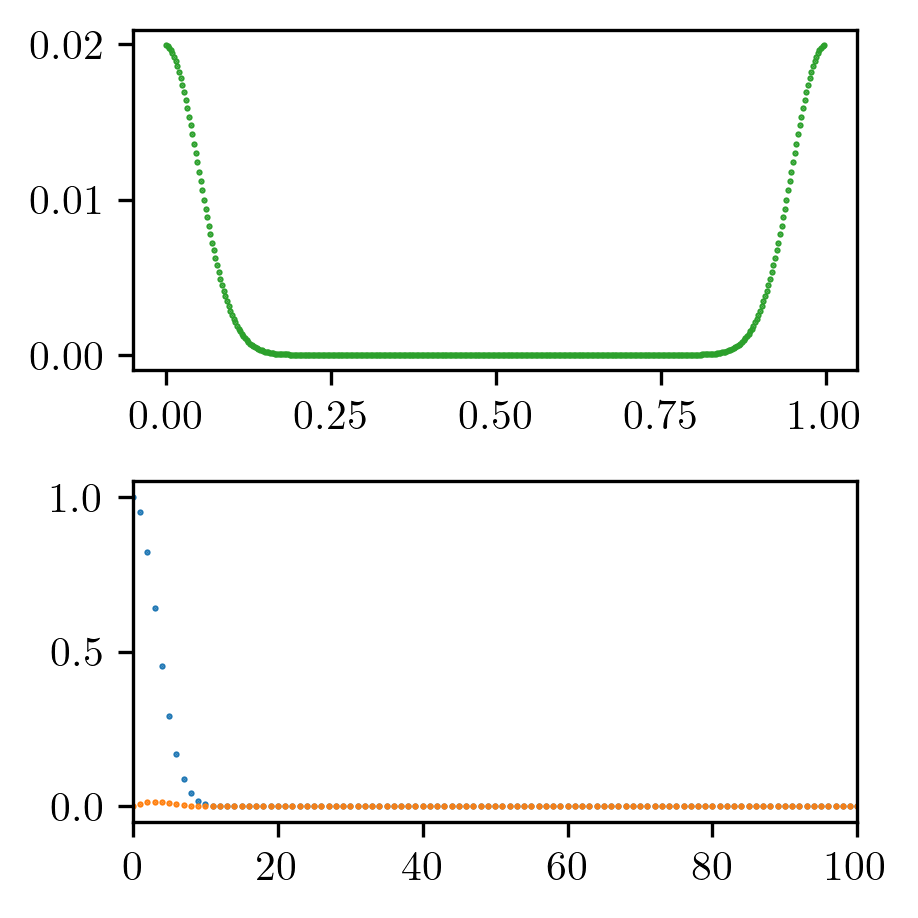

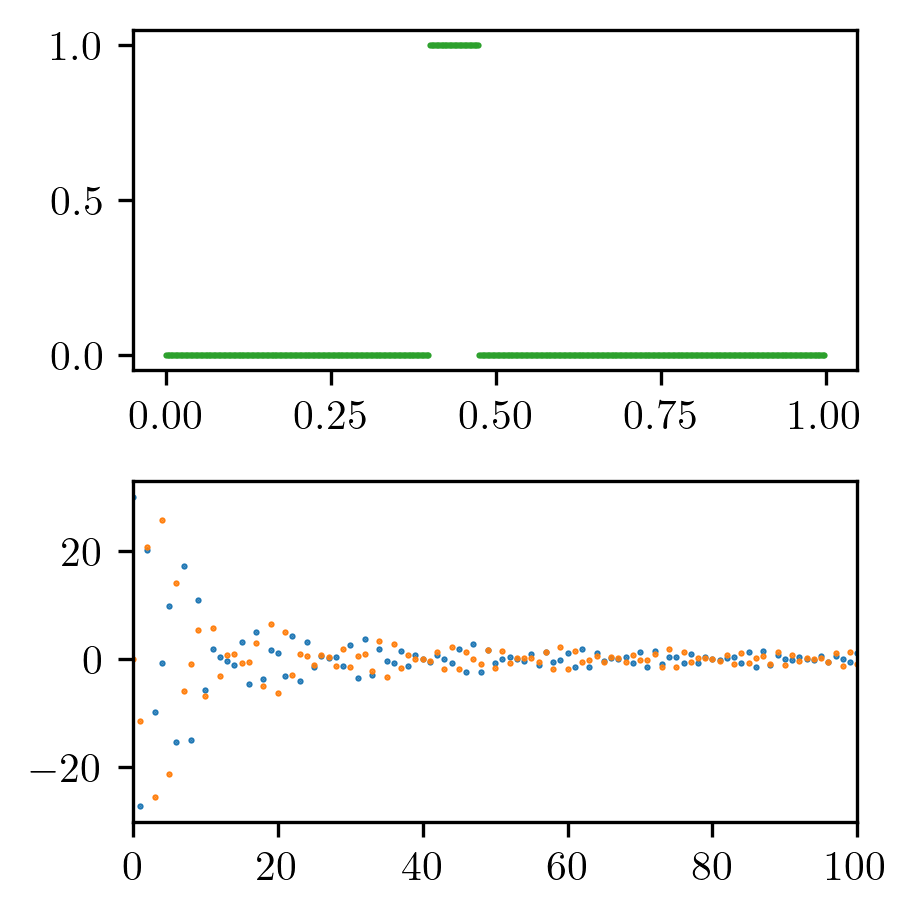

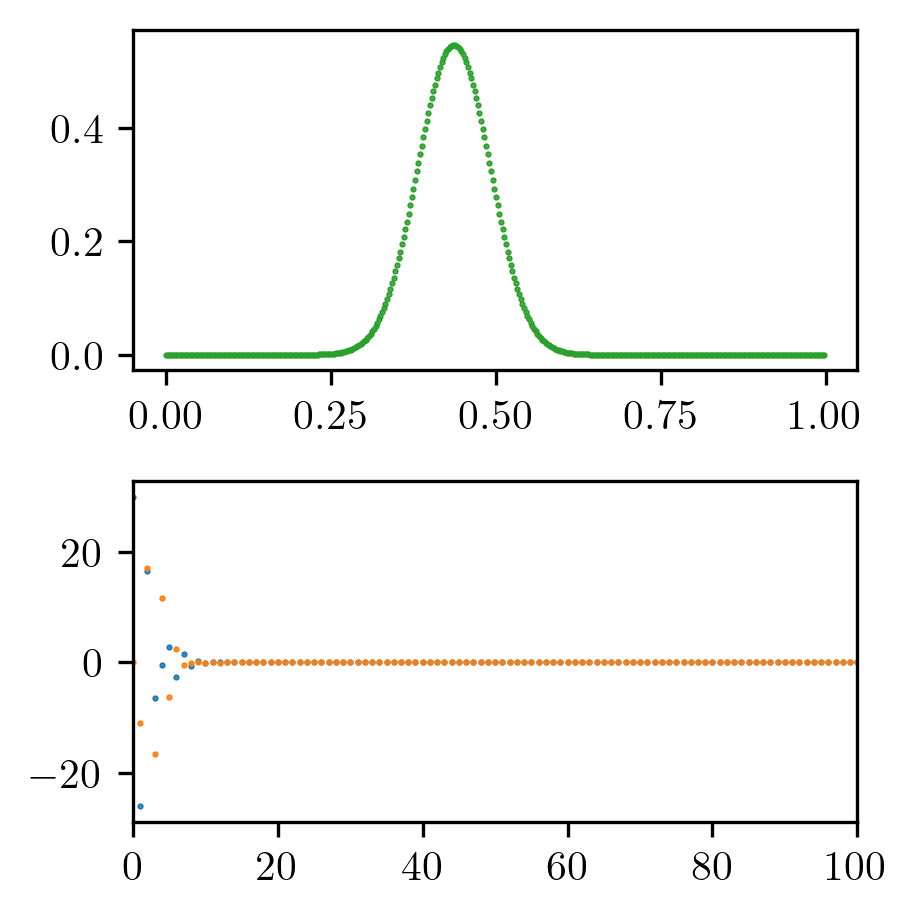

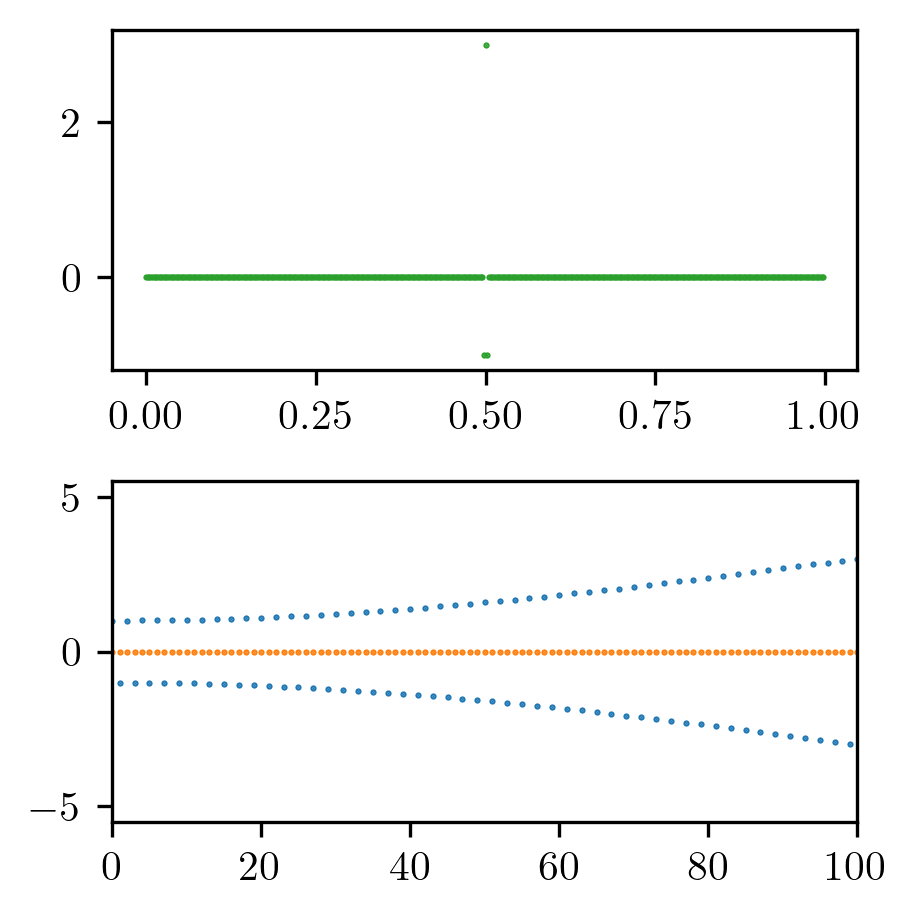

In [29]:
sharpening = np.zeros_like(psf)
sharpening[199] = -1
sharpening[200] = 3
sharpening[201] = -1
signals = [ifftshift(psf.ravel()), X[:, 4], X_c[:, 4], sharpening]
signals_f = []
for signal in signals:
    signal = signal.ravel()
    signal_f = (fft(signal))
    signals_f.append(signal_f)
    fig, (ax1, ax2) = plt.subplots(2, 1)
    #ax1.plot(x, psf, "C1.", ms=1)
    ax1.plot(x, signal, "C2.", ms=1)
    ax2.plot(freq[positiv_only], signal_f[positiv_only].real, "C0.", label="cos", ms=1)
    ax2.plot(freq[positiv_only], signal_f[positiv_only].imag, "C1.", label="sin", ms=1)
    ax2.set_xlim([0, len(x)/4])
    plt.show()


C:\Users\florianma\AppData\Local\Temp\ipykernel_4432\670170469.py:1: RuntimeWarning: divide by zero encountered in true_divide
  to_be_transformed_back = [signals_f[0], signals_f[1], signals_f[2], signals_f[0]*signals_f[1], 1/signals_f[0]]
C:\Users\florianma\AppData\Local\Temp\ipykernel_4432\670170469.py:1: RuntimeWarning: invalid value encountered in true_divide
  to_be_transformed_back = [signals_f[0], signals_f[1], signals_f[2], signals_f[0]*signals_f[1], 1/signals_f[0]]


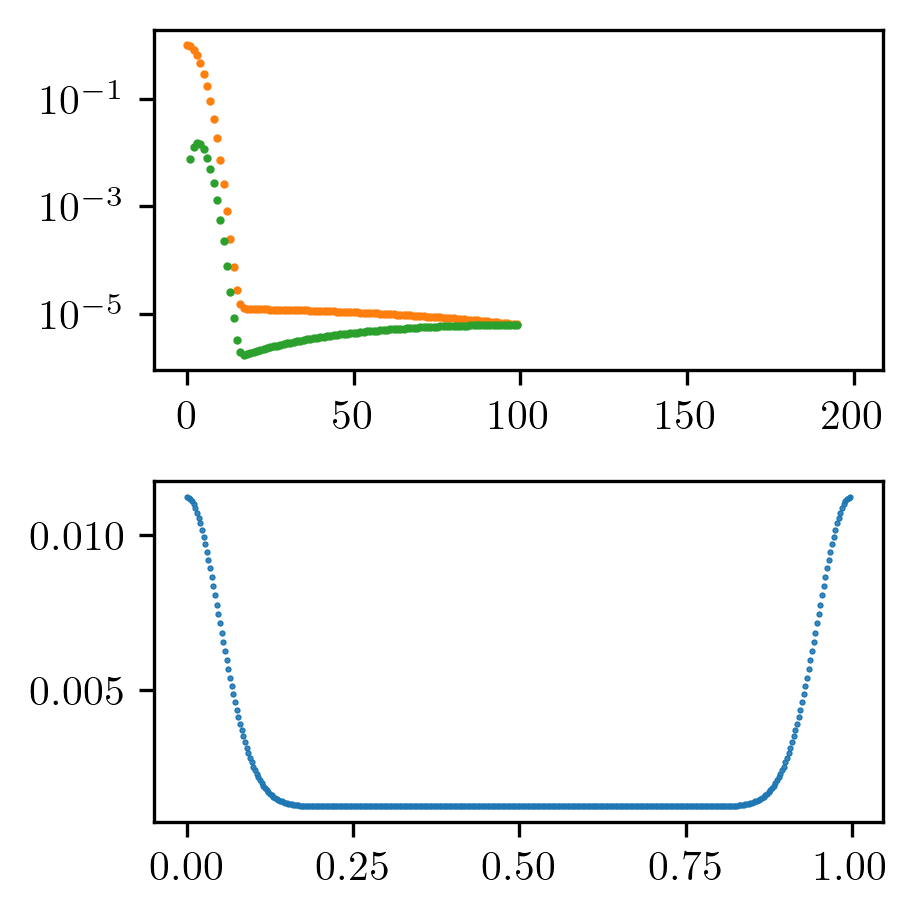

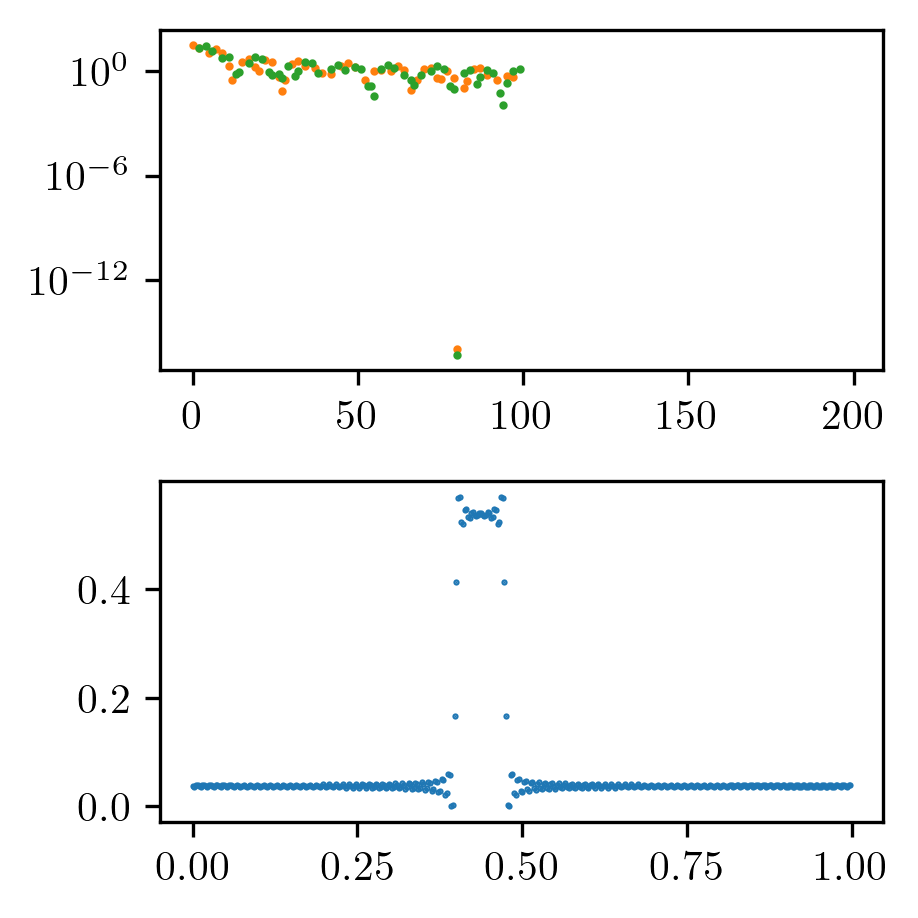

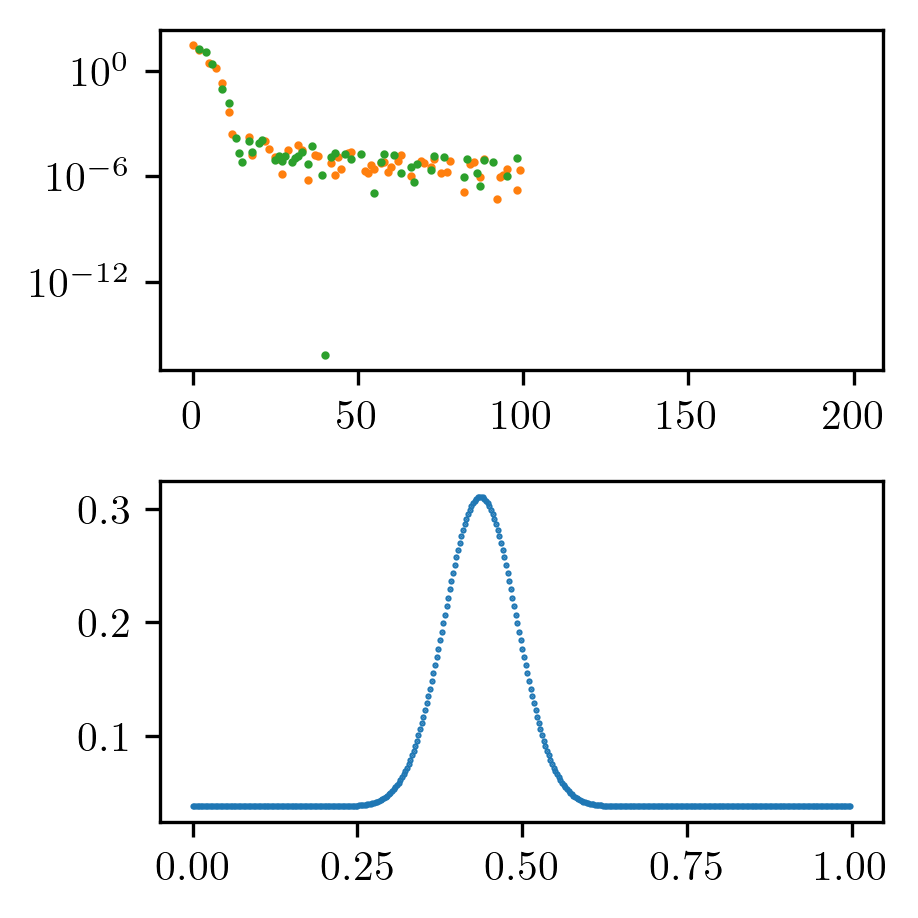

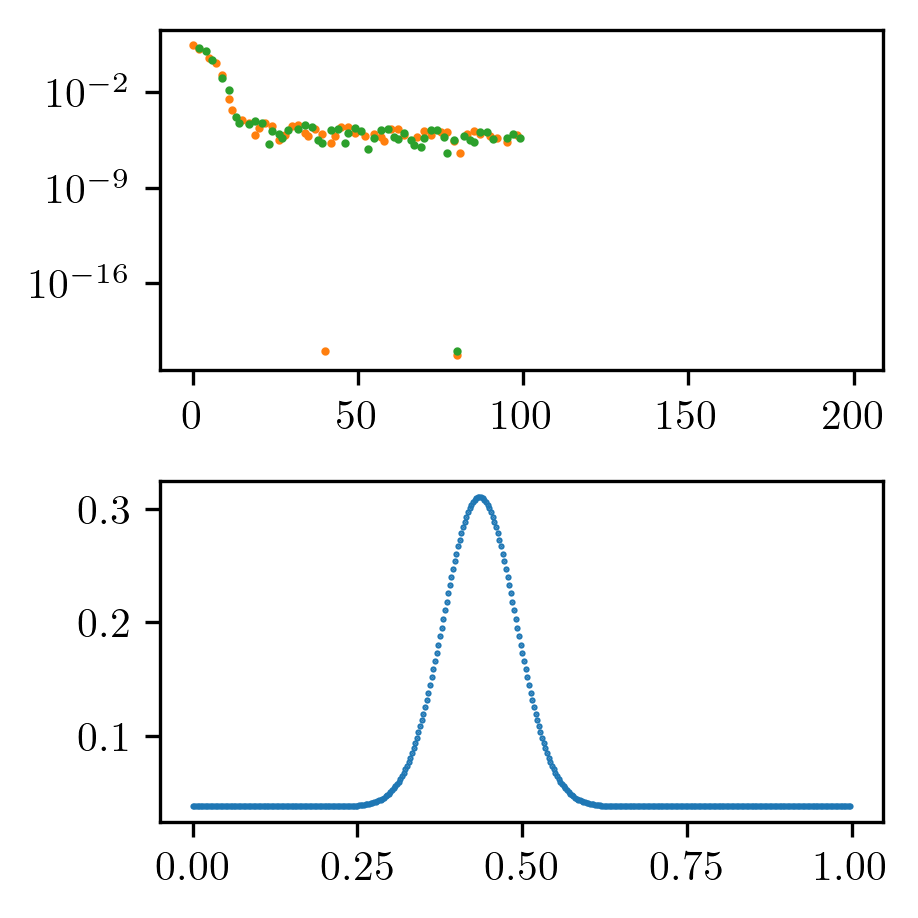

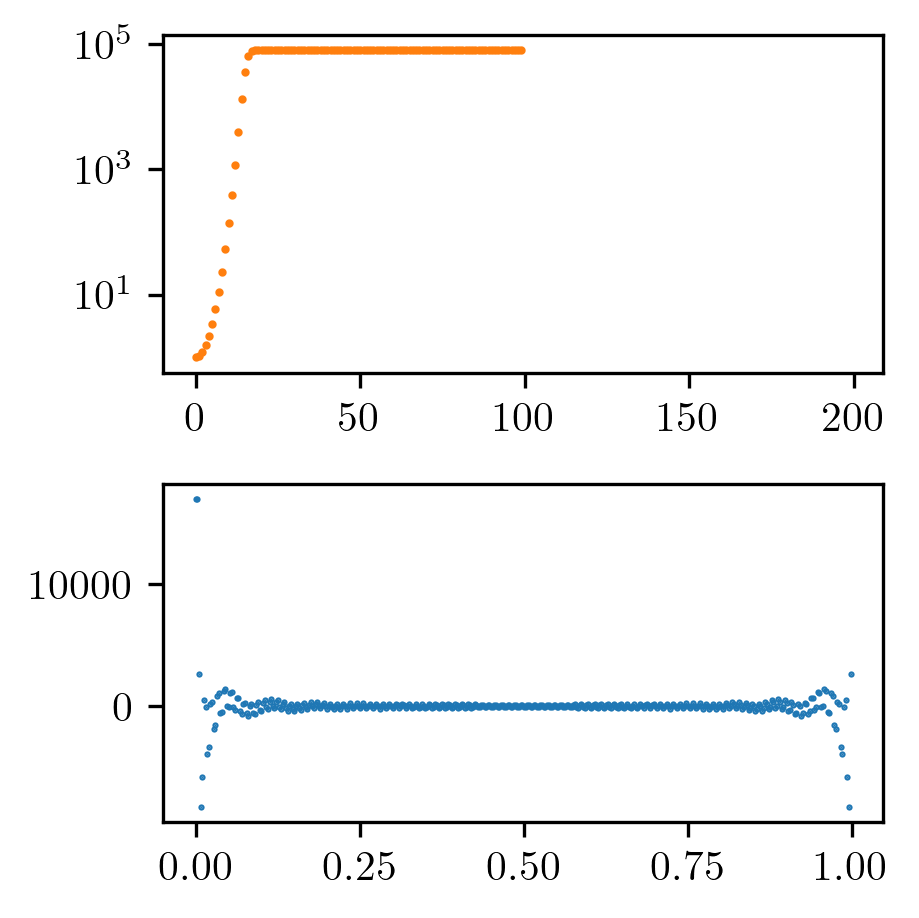

In [17]:
to_be_transformed_back = [signals_f[0], signals_f[1], signals_f[2], signals_f[0]*signals_f[1], 1/signals_f[0]]
for signal_f in to_be_transformed_back:
    signal_f = signal_f.copy()
    signal_f[np.isnan(signal_f)] = 0
    signal_f[signal_f>1e6] = 0
    signal_f[signal_f<-1e6] = 0
    cutoff_frequ = 100
    low_pass = (-cutoff_frequ < freq) & (freq < cutoff_frequ)
    signal_f[~low_pass] = 0
    signal_f[~positiv_only] = 0
    signal = ifft(signal_f).real
    
    fig, (ax1, ax2) = plt.subplots(2, 1)
              
    ax1.plot(freq[positiv_only], signal_f[positiv_only].real, "C1o", label="cos", ms=1)
    ax1.plot(freq[positiv_only], signal_f[positiv_only].imag, "C2o", label="sin", ms=1)
    ax1.set_yscale('log')

    ax2.plot(x, signal, "C0.", ms=1)


#     signal_f = signals_f[0]*signals_f[1]
#     ax2.plot(freq, signal_f.real, "C0.", label="cos", ms=1)
#     ax2.plot(freq, signal_f.imag, "C1.", label="sin", ms=1)
#     ax2.set_xlim([0, 50])
    plt.show()

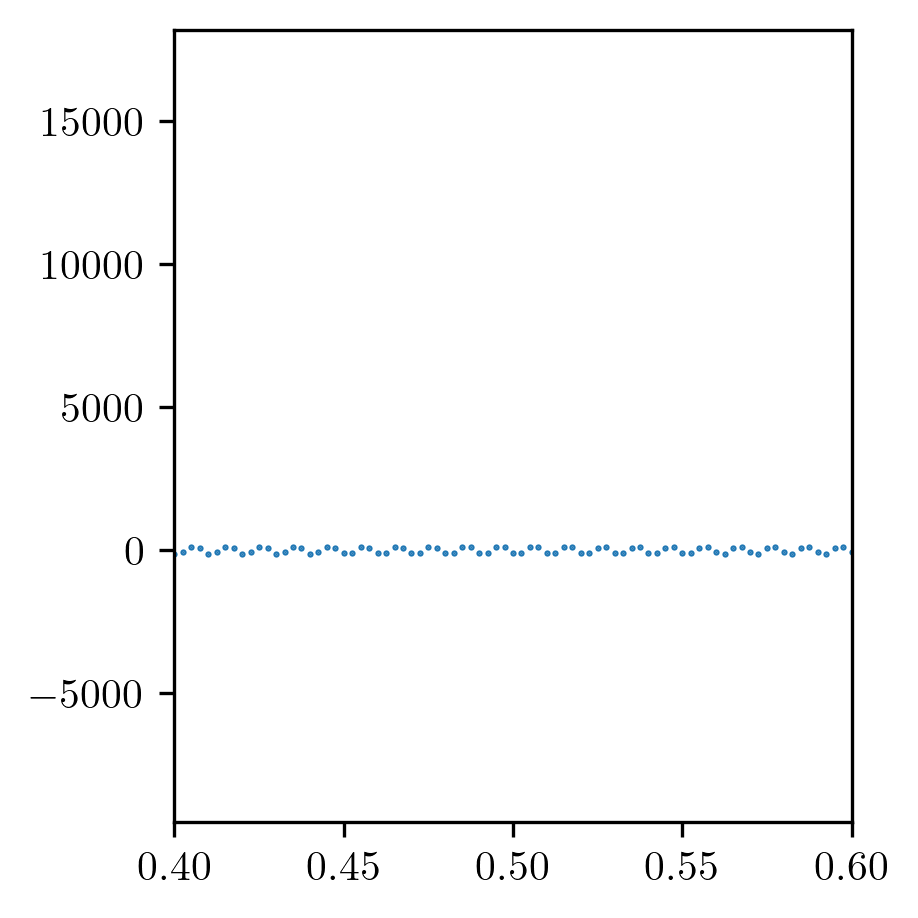

In [18]:
plt.plot(x, signal, "C0.", ms=1)
plt.xlim([.4, .6])
plt.show()